# Multi-Constraint Scaling Study

This notebook tests how MVR + Viterbi scales with the number of simultaneous constraints. The underlying HMM is fixed and the number of regular constraints applied during decoding is varied. For each configuration we record per-run wall-clock time, peak GPU memory, and the size of the augmented state space.

The primary constraint pool consists of hitting constraints, each on a distinct state. A hitting constraint has mediation space size 2, so the augmented state space grows as $K \cdot 2^n$ in the number of constraints $n$. This isolates the multiplicative blowup that the paper claims as a structural cost of the framework. A second cell at the end demonstrates a heterogeneous mix of constraints (hitting, counting, precedence) at one configuration.

In [31]:
# %pip install --upgrade ipython
# %pip install numpy matplotlib munch

In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import numpy as np
import torch
import copy
import time
import pickle
import gc
import matplotlib.pyplot as plt
from munch import Munch

from ICML_comparisons import generate_random_hmm
from ICML_MVRseq import Viterbi_torch_list
from helper import sample_hmm

In [4]:
torch.cuda.empty_cache()
gc.collect()
torch.cuda.empty_cache()

## 1. Constraint constructors

Three regular-constraint families are defined here. Each constructor returns a `Munch` object with `update_fun`, `init_fun`, `eval_fun`, and `m_states`. The mediation space sizes are recorded in comments so the multiplicative cost is transparent.

In [5]:
def make_hitting_constraint(target_state):
    """
    Constraint: target_state must be visited at some point.
    Mediation space size: 2.
    """
    m_states = [False, True]

    def init_fun(k, r):
        return r == (k == target_state)

    def update_fun(k, r, r_past):
        return r == (r_past or (k == target_state))

    def eval_fun(k, r):
        return r == True

    return copy.deepcopy(Munch(
        update_fun=update_fun,
        init_fun=init_fun,
        eval_fun=eval_fun,
        m_states=m_states,
    ))

In [6]:
def make_count_at_least_constraint(target_state, count_min):
    """
    Constraint: target_state must occur at least count_min times.
    Mediation space size: count_min + 1.
    """
    m_states = list(range(count_min + 1))

    def init_fun(k, r):
        if k == target_state:
            return r == 1
        return r == 0

    def update_fun(k, r, r_past):
        if k == target_state:
            return r == min(r_past + 1, count_min)
        return r == r_past

    def eval_fun(k, r):
        return r >= count_min

    return copy.deepcopy(Munch(
        update_fun=update_fun,
        init_fun=init_fun,
        eval_fun=eval_fun,
        m_states=m_states,
    ))

In [7]:
def make_precedence_constraint(state_A, state_B):
    """
    Constraint: state_A must occur strictly before state_B.
    Mediation space size: 4.
      0: nothing seen yet
      1: A seen first
      2: B before A (rejecting absorbing state)
      3: A then B (accepting absorbing state)
    """
    m_states = [0, 1, 2, 3]

    def init_fun(k, r):
        if k == state_A:
            return r == 1
        if k == state_B:
            return r == 2
        return r == 0

    def update_fun(k, r, r_past):
        if r_past == 2:
            return r == 2
        if r_past == 3:
            return r == 3
        if r_past == 0:
            if k == state_A:
                return r == 1
            if k == state_B:
                return r == 2
            return r == 0
        if r_past == 1:
            if k == state_B:
                return r == 3
            return r == 1
        return False

    def eval_fun(k, r):
        return r == 3

    return copy.deepcopy(Munch(
        update_fun=update_fun,
        init_fun=init_fun,
        eval_fun=eval_fun,
        m_states=m_states,
    ))

## 2. Experiment setup

The HMM has `K = 100` hidden states and 10 emission symbols. Sequences are length `T = 100`, with 25 observation draws per configuration. The number of constraints sweeps from 1 to 8.

In [58]:
# 100
num_states = 100
# 10
num_emissions = 10
# 100
T = 100
# 25
batch = 25
# list(range(1, 9))
n_constraints_list = list(range(1, 10))
seed_hmm = 42

In [59]:
# Generate HMM
hmm_params = generate_random_hmm(num_states, num_emissions, seed=seed_hmm)
transition_matrix, emission_matrix, initial_vector = hmm_params

hidden_states = list(range(num_states))
emit_states = list(range(num_emissions))
hidden_size, emit_size = len(hidden_states), len(emit_states)

hmm_transition = {}
for i in range(hidden_size):
    for j in range(hidden_size):
        hmm_transition[hidden_states[i], hidden_states[j]] = transition_matrix[i, j].item()

hmm_emit = {}
for i in range(hidden_size):
    for j in range(emit_size):
        hmm_emit[hidden_states[i], emit_states[j]] = emission_matrix[i, j].item()

hmm_startprob = {}
for i in range(hidden_size):
    hmm_startprob[hidden_states[i]] = initial_vector[i]

hmm = copy.deepcopy(Munch(
    states=hidden_states,
    emits=emit_states,
    tprob=hmm_transition,
    eprob=hmm_emit,
    initprob=hmm_startprob,
))

print(f'Generated HMM with {num_states} hidden states and {num_emissions} emissions')

Generated HMM with 100 hidden states and 10 emissions


## 3. Main scaling experiment

For each `n` in `n_constraints_list`, we instantiate `n` hitting constraints on states $0, 1, \ldots, n-1$ and time the constrained Viterbi pass over `batch` independently sampled observation sequences. Peak GPU memory is read with `torch.cuda.max_memory_allocated`, reset before each run. `torch.cuda.synchronize` is used to ensure GPU work is complete before timing or memory readings.

If a configuration triggers OOM the run is recorded as `None` and the loop continues, allowing the experiment to characterize the failure point cleanly.

In [60]:
def reset_gpu_memory(device='cuda:0'):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

# Safe peak GPU memory function
def peak_gpu_memory_mb(device=None):
    if torch.cuda.is_available() and device is not None:
        return torch.cuda.max_memory_allocated(device) / 1024**2
    else:
        return None

In [61]:
def reset_gpu_memory(device='cuda:0'):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

# Safe peak GPU memory function
def peak_gpu_memory_mb(device=None):
    if torch.cuda.is_available() and device is not None:
        return torch.cuda.max_memory_allocated(device) / 1024**2
    else:
        return None


In [62]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f'Current device is {torch.cuda.current_device()}')

Using device: cuda:0
Current device is 0


For some reason, ```reset_peak_memory_stats``` doesn't work even if the argument is an int, torch.device, or string. Instead, since it default to "current_device()" is which current is the gpu.

In [63]:
results = {
    'n_constraints': [],
    'augmented_size': [],
    'times': [],
    'gpu_mem_mb': [],
}

for n in n_constraints_list:
    cst_list = [make_hitting_constraint(s) for s in range(n)]
    aug_size = num_states * (2 ** n)

    print(f'--- n_constraints = {n}, augmented state space = {aug_size} ---')

    times_batch = []
    mem_batch = []

    for b in range(batch):
        if b % 5 == 0:
            print(f'  run {b}/{batch}')

        states, observations = sample_hmm(hmm, T)

        reset_gpu_memory() #delete device arg
        try:
            # Only synchronize if GPU is available
            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.time()

            # Call Viterbi function on the detected device
            opt_state_list, opt_augstateix_list = Viterbi_torch_list(
                hmm, cst_list, observations,
                dtype=torch.float32,
                device=device,
                debug=False,
                num_corr=0,
            )

            if device.type == "cuda":
                torch.cuda.synchronize()
            time_elapsed = time.time() - start

            mem_used = peak_gpu_memory_mb(device=device)

        except RuntimeError as e:
            # Catch both GPU OOM and CPU runtime errors
            print(f'  Runtime error at n_constraints={n}, batch={b}: {e}')
            time_elapsed = None
            mem_used = None

        times_batch.append(time_elapsed)
        mem_batch.append(mem_used)

    results['n_constraints'].append(n)
    results['augmented_size'].append(aug_size)
    results['times'].append(times_batch)
    results['gpu_mem_mb'].append(mem_batch)

print('Done.')

--- n_constraints = 1, augmented state space = 200 ---
  run 0/25
  run 5/25
  run 10/25
  run 15/25
  run 20/25
--- n_constraints = 2, augmented state space = 400 ---
  run 0/25
  run 5/25
  run 10/25
  run 15/25
  run 20/25
--- n_constraints = 3, augmented state space = 800 ---
  run 0/25
  run 5/25
  run 10/25
  run 15/25
  run 20/25
--- n_constraints = 4, augmented state space = 1600 ---
  run 0/25
  run 5/25
  run 10/25
  run 15/25
  run 20/25
--- n_constraints = 5, augmented state space = 3200 ---
  run 0/25
  run 5/25
  run 10/25
  run 15/25
  run 20/25
--- n_constraints = 6, augmented state space = 6400 ---
  run 0/25
  run 5/25
  run 10/25
  run 15/25
  run 20/25
--- n_constraints = 7, augmented state space = 12800 ---
  run 0/25
  run 5/25
  run 10/25
  run 15/25
  run 20/25
--- n_constraints = 8, augmented state space = 25600 ---
  run 0/25
  run 5/25
  run 10/25
  run 15/25
  run 20/25
--- n_constraints = 9, augmented state space = 51200 ---
  run 0/25
  run 5/25
  run 10/2

In [79]:
with open('multi_constraint_scaling.pkl', 'wb') as f:
    pickle.dump(results, f)
print('Saved results to multi_constraint_scaling.pkl')

# with open('multi_constraint_scaling.pkl', 'rb') as f:
#     results = pickle.load(f)


Saved results to multi_constraint_scaling.pkl


## 4. Visualizing the scaling

Mean and 95% CI over the batch for each constraint count. Configurations that hit OOM contribute fewer points; the helper below filters them and adjusts the CI for sample size.

In [80]:
def mean_and_ci(values_list):
    """Returns (mean array, half-width 95% CI array), filtering None entries."""
    means = []
    cis = []
    for vals in values_list:
        clean = [v for v in vals if v is not None]
        if len(clean) == 0:
            means.append(np.nan)
            cis.append(np.nan)
        else:
            arr = np.array(clean)
            means.append(arr.mean())
            cis.append(1.96 * arr.std(ddof=1) / np.sqrt(len(arr)))
    return np.array(means), np.array(cis)

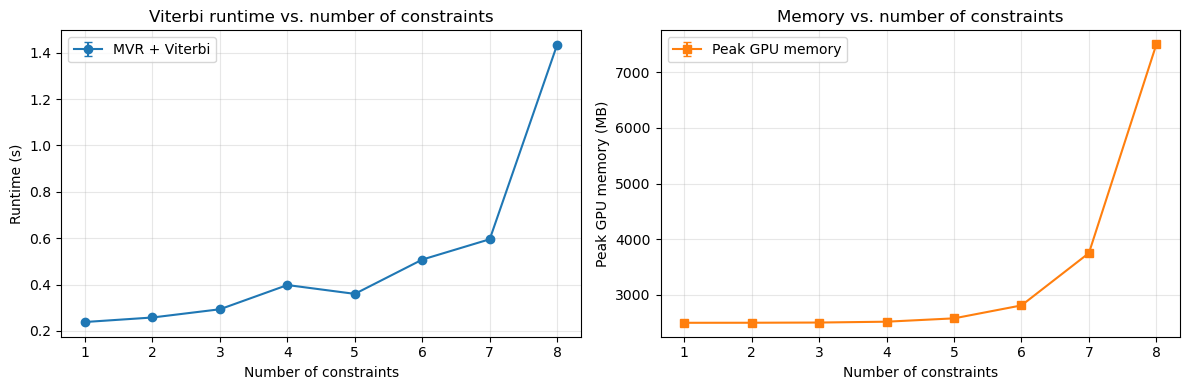

In [85]:
mean_times, ci_times = mean_and_ci(results['times'])
mean_mem, ci_mem = mean_and_ci(results['gpu_mem_mb'])
n_arr = np.array(results['n_constraints'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.errorbar(n_arr, mean_times, yerr=ci_times, marker='o', capsize=3,
             label='MVR + Viterbi')
ax1.set_xlabel('Number of constraints')
ax1.set_ylabel('Runtime (s)')
# ax1.set_title(f'Runtime vs. number of constraints\n(K={num_states}, T={T}, hitting constraints)')
ax1.set_title('Viterbi runtime vs. number of constraints')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.errorbar(n_arr, mean_mem, yerr=ci_mem, marker='s', color='C1', capsize=3,
             label='Peak GPU memory')
ax2.set_xlabel('Number of constraints')
ax2.set_ylabel('Peak GPU memory (MB)')
# ax2.set_title(f'Memory vs. number of constraints\n(K={num_states}, T={T}, hitting constraints)')
ax2.set_title('Memory vs. number of constraints')

ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('scaling_constraints_ttl.pdf', format='png', dpi=300, bbox_inches='tight')
plt.show()

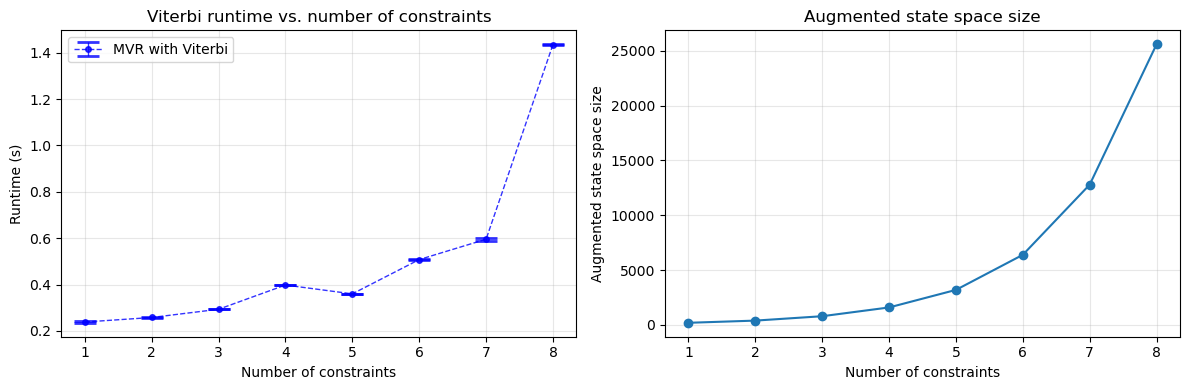

In [95]:
mean_times, ci_times = mean_and_ci(results['times'])
mean_mem, ci_mem = mean_and_ci(results['gpu_mem_mb'])
n_arr = np.array(results['n_constraints'])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Runtime plot with error bars
ax1.errorbar(
    n_arr,
    mean_times,
    yerr=ci_times,
    fmt='o--',
    color='blue',
    label='MVR with Viterbi',
    capsize=8,
    capthick=2,
    linewidth=1,
    markersize=4,
    alpha=0.8
)
ax1.set_xlabel('Number of constraints')
ax1.set_ylabel('Runtime (s)')
# ax1.set_title(f'Runtime vs. number of constraints\n(K={num_states}, T={T}, hitting constraints)')
ax1.set_title('Viterbi runtime vs. number of constraints')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Augmented state space size plot (original logic retained)
ax2.plot(n_arr, results['augmented_size'], marker='o')
ax2.set_xlabel('Number of constraints')
ax2.set_ylabel('Augmented state space size')
ax2.set_title(f'Augmented state space size')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('scaling_constraints_ttl.pdf', format='png', dpi=300, bbox_inches='tight')
plt.show()


ax2.errorbar(n_arr, mean_mem, yerr=ci_mem, marker='s', color='C1', capsize=3,
             label='Peak GPU memory')
ax2.set_xlabel('Number of constraints')
ax2.set_ylabel('Peak GPU memory (MB)')
# ax2.set_title(f'Memory vs. number of constraints\n(K={num_states}, T={T}, hitting constraints)')
ax2.set_title('Memory vs. number of constraints')

ax2.grid(True, alpha=0.3)
ax2.legend()


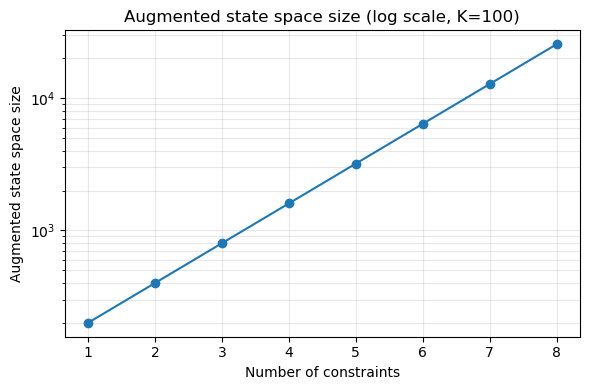

In [82]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(n_arr, results['augmented_size'], marker='o')
ax.set_xlabel('Number of constraints')
ax.set_ylabel('Augmented state space size')
ax.set_title(f'Augmented state space size (log scale, K={num_states})')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

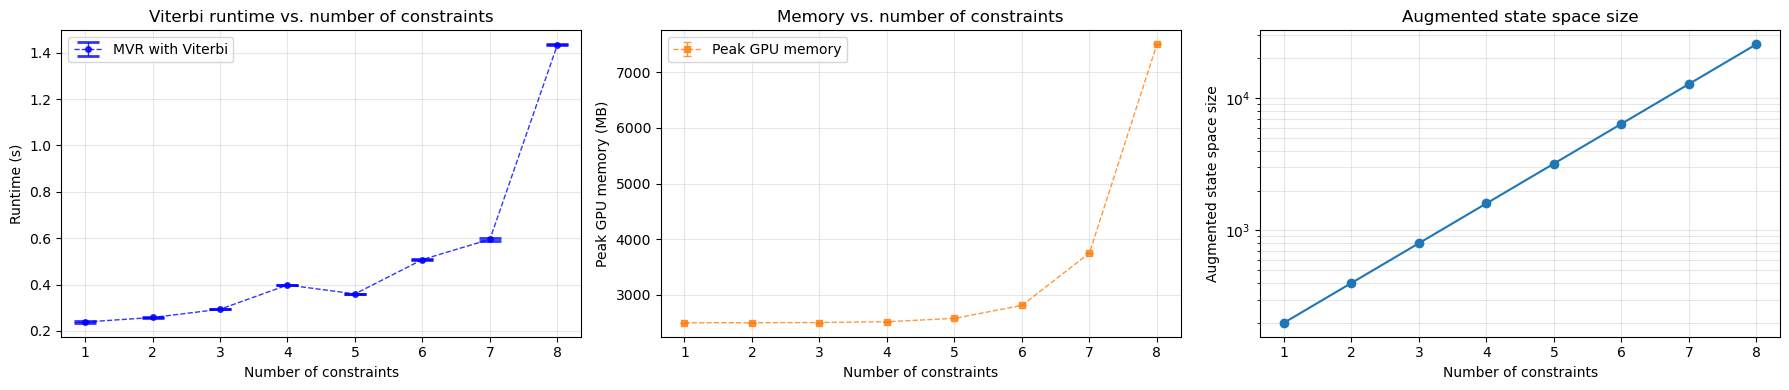

In [101]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

# 1) Runtime plot
ax1.errorbar(
    n_arr,
    mean_times,
    yerr=ci_times,
    fmt='o--',
    color='blue',
    label='MVR with Viterbi',
    capsize=8,
    capthick=2,
    linewidth=1,
    markersize=4,
    alpha=0.8
)
ax1.set_xlabel('Number of constraints')
ax1.set_ylabel('Runtime (s)')
ax1.set_title('Viterbi runtime vs. number of constraints')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2) Memory usage plot
ax2.errorbar(
    n_arr,
    mean_mem,
    yerr=ci_mem,
    fmt='s--',
    color='C1',
    label='Peak GPU memory',
    capsize=3,
    linewidth=1,
    markersize=4,
    alpha=0.8
)
ax2.set_xlabel('Number of constraints')
ax2.set_ylabel('Peak GPU memory (MB)')
ax2.set_title('Memory vs. number of constraints')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3) Augmented state space size plot
ax3.semilogy(n_arr, results['augmented_size'], marker='o')
ax3.set_xlabel('Number of constraints')
ax3.set_ylabel('Augmented state space size')
ax3.set_title('Augmented state space size')
ax3.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('scaling_constraints_all_three.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 5. Heterogeneous constraint demonstration

A complementary single-configuration experiment with a mix of constraint types. This demonstrates that the framework handles different constraint families simultaneously, not only homogeneous ones. The augmented state space here is $K \cdot 2 \cdot 4 \cdot 4 \cdot 2$, equivalent in size to roughly six hitting constraints.

In [18]:
mixed_pool = [
    make_hitting_constraint(target_state=0),                      # |M| = 2
    make_count_at_least_constraint(target_state=1, count_min=3),  # |M| = 4
    make_precedence_constraint(state_A=2, state_B=3),             # |M| = 4
    make_hitting_constraint(target_state=4),                      # |M| = 2
]

aug_size_mixed = num_states * 2 * 4 * 4 * 2
print(f'Mixed-pool augmented state space: {aug_size_mixed}')
for i, cst in enumerate(mixed_pool):
    print(f'  constraint {i}: |M_i| = {len(cst.m_states)}')

Mixed-pool augmented state space: 6400
  constraint 0: |M_i| = 2
  constraint 1: |M_i| = 4
  constraint 2: |M_i| = 4
  constraint 3: |M_i| = 2


In [19]:
# FOR CPU TESTING ONLY
#num_states = 20
#num_emissions = 10
#T = 30
#batch = 3
#n_constraints_list = list(range(1, 5))  # n = 1, 2, 3, 4

In [20]:
times_mixed = []
mem_mixed = []

for b in range(batch):
    if b % 5 == 0:
        print(f'  run {b}/{batch}')

    states, observations = sample_hmm(hmm, T)
    reset_gpu_memory(device=device)
    # Update this to current cpu memory utilization
    baseline = 0

    try:
        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.time()
        opt_state_list, opt_augstateix_list = Viterbi_torch_list(
            hmm, mixed_pool, observations,
            dtype=torch.float32, device=device, debug=False, num_corr=0,
        )
        if device.type == "cuda":
            torch.cuda.synchronize()
        times_mixed.append(time.time() - start)
        mem_mixed.append(peak_gpu_memory_mb(device=device))
    except (RuntimeError, MemoryError) as e:
        print(f'  Failed at batch {b}: {e}')
        times_mixed.append(None)
        mem_mixed.append(None)

clean_times = [t for t in times_mixed if t is not None]
clean_mem = [m for m in mem_mixed if m is not None]

if len(clean_times) > 0:
    t_mean = np.mean(clean_times)
    t_ci = 1.96 * np.std(clean_times, ddof=1) / np.sqrt(len(clean_times))
    print(f'\nMixed configuration ({len(clean_times)}/{batch} successful runs):')
    print(f'  Runtime:     {t_mean:.4f} s ± {t_ci:.4f}')
    if clean_mem:
        m_mean = np.mean(clean_mem)
        m_ci = 1.96 * np.std(clean_mem, ddof=1) / np.sqrt(len(clean_mem))
        print(f'  Peak memory: {m_mean:.1f} MB ± {m_ci:.1f}')

with open('multi_constraint_mixed.pkl', 'wb') as f:
    pickle.dump({
        'times': times_mixed,
        'gpu_mem_mb': mem_mixed,
        'aug_size': aug_size_mixed,
        'device': device,
    }, f)
print('Saved mixed results to multi_constraint_mixed.pkl')

  run 0/25
  run 5/25
  run 10/25
  run 15/25
  run 20/25

Mixed configuration (25/25 successful runs):
  Runtime:     0.4793 s ± 0.0072
  Peak memory: 312.7 MB ± 0.0
Saved mixed results to multi_constraint_mixed.pkl


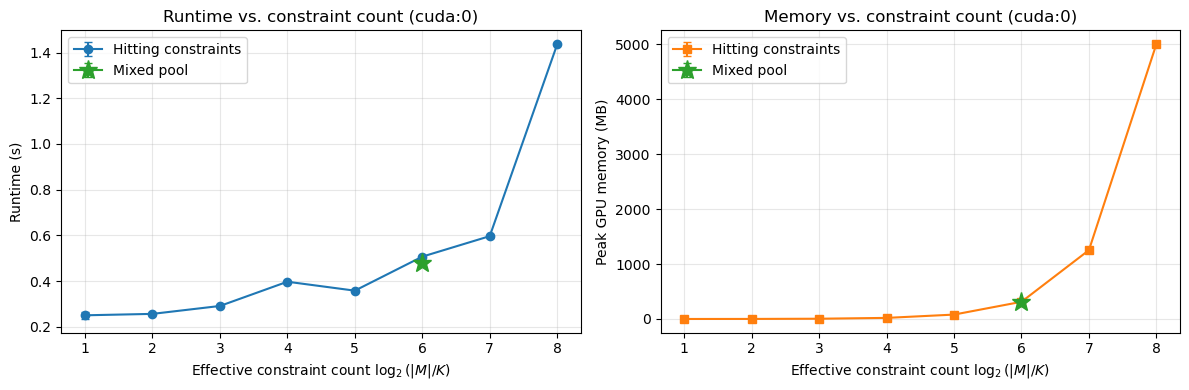

In [21]:
mean_times, ci_times = mean_and_ci(results['times'])
mean_mem, ci_mem = mean_and_ci(results['gpu_mem_mb'])
n_arr = np.array(results['n_constraints'])

# The mixed pool's |M_i| product is 2*4*4*2 = 64 = 2^6, equivalent to 6 hitting constraints.
n_equiv_mixed = np.log2(aug_size_mixed / num_states)

t_mean_mixed = np.mean(clean_times) if clean_times else np.nan
t_ci_mixed = (1.96 * np.std(clean_times, ddof=1) / np.sqrt(len(clean_times))) if len(clean_times) > 1 else 0.0

m_mean_mixed = np.mean(clean_mem) if clean_mem else np.nan
m_ci_mixed = (1.96 * np.std(clean_mem, ddof=1) / np.sqrt(len(clean_mem))) if len(clean_mem) > 1 else 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.errorbar(n_arr, mean_times, yerr=ci_times, marker='o', capsize=3,
             label='Hitting constraints')
ax1.errorbar([n_equiv_mixed], [t_mean_mixed], yerr=[t_ci_mixed],
             marker='*', markersize=14, color='C2', capsize=3,
             label='Mixed pool')
ax1.set_xlabel(r'Effective constraint count $\log_2(|M|/K)$')
ax1.set_ylabel('Runtime (s)')
ax1.set_title(f'Runtime vs. constraint count ({device})')
ax1.grid(True, alpha=0.3)
ax1.legend()

if device.type == "cuda":
    mem_label = 'Peak GPU memory (MB)'
else:
    mem_label = 'CPU Memory (MB)'
ax2.errorbar(n_arr, mean_mem, yerr=ci_mem, marker='s', color='C1', capsize=3,
             label='Hitting constraints')
ax2.errorbar([n_equiv_mixed], [m_mean_mixed], yerr=[m_ci_mixed],
             marker='*', markersize=14, color='C2', capsize=3,
             label='Mixed pool')
ax2.set_xlabel(r'Effective constraint count $\log_2(|M|/K)$')
ax2.set_ylabel(mem_label)
ax2.set_title(f'Memory vs. constraint count ({device})')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()